# Drone Detection with YOLO26m

This notebook builds an end-to-end drone detection pipeline using **YOLO26m** fine-tuned on a real-world drone dataset.

We start by exploring the data, visualise augmentations, integrate a ResNet50 binary classifier as a second-opinion layer, train YOLO26m, then evaluate on unseen real-world images.

---

## Table of Contents

1. [Setup](#1-setup)
   - 1.1 [Imports](#11-imports)
   - 1.2 [Dataset Paths & YAML](#12-dataset-paths--yaml)
   - 1.3 [Hyperparameters & Augmentation Pipeline](#13-hyperparameters--augmentation-pipeline)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
   - 2.1 [Image Shapes](#21-image-shapes)
   - 2.2 [Random Sample Viewer](#22-random-sample-viewer)
   - 2.3 [Object Crops from Labels](#23-object-crops-from-labels)
3. [Augmentation Preview](#3-augmentation-preview)
4. [Drone Classifier (ResNet50)](#4-drone-classifier-resnet50)
   - 4.1 [Load Classifier & Inference Function](#41-load-classifier--inference-function)
   - 4.2 [Visualise Classifier on Dataset](#42-visualise-classifier-on-dataset)
   - 4.3 [Visualise with Bounding Box Overlay](#43-visualise-with-bounding-box-overlay)
5. [YOLO26m — Pre-Training Inference](#5-yolo26m--pre-training-inference)
   - 5.1 [Load Base Model](#51-load-base-model)
   - 5.2 [Predict & Plot](#52-predict--plot)
6. [Training](#6-training)
7. [Evaluation](#7-evaluation)
   - 7.1 [Test on Real-World Images](#71-test-on-real-world-images)
   - 7.2 [Confusion Matrix](#72-confusion-matrix)
   - 7.3 [Training Curves](#73-training-curves)

## 1. Setup

### 1.1 Imports

In [ ]:
import numpy as np
from glob import glob
from ultralytics import YOLO
from yaml import safe_load,
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import warnings as warn
import os
import torch
from keras.models import load_model
from keras.applications.resnet50 import preprocess_input

warn.simplefilter('ignore')

### 1.2 Dataset Paths & YAML

We load `data.yaml` from the dataset root, then patch the `train` and `val` paths to absolute locations.
YOLO requires absolute paths to find images reliably across different working directories.

In [ ]:
DS_PATH= r'..\..\..\..\World Of Datasets\Un-Structured Datasets\Object Detection\Drones Detection Dataset\drone_dataset'
DATA_YAML_PATH = os.path.join(DS_PATH,'data.yaml') 

with open(DATA_YAML_PATH, 'r', encoding='utf-8') as file:
    yaml_data = safe_load(file)
yaml_data

{'names': ['drone'],
 'nc': 1,
 'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\valid\\images'}

In [ ]:
new_train_path = os.path.join(DS_PATH, 'train', 'images')
new_val_path   = os.path.join(DS_PATH, 'valid', 'images')

# overwrite relative paths with absolute ones so YOLO can resolve them
yaml_data['train'] = new_train_path
yaml_data['val']   = new_val_path

yaml_data

{'names': ['drone'],
 'nc': 1,
 'train': '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\train\\images',
 'val': '..\\..\\..\\..\\World Of Datasets\\Un-Structured Datasets\\Object Detection\\Drones Detection Dataset\\drone_dataset\\valid\\images'}

### 1.3 Hyperparameters & Augmentation Pipeline

All training hyperparameters are defined here.
The augmentation pipeline simulates real-world conditions: motion blur (fast-moving drones), occlusion via `CoarseDropout` (a hand partially covering the drone), brightness shifts (outdoor lighting), rotation and shear (varied angles), and compression artefacts (low-quality cameras).

In [ ]:
CONF           = 0.20          # minimum confidence threshold for YOLO detections

EPOCHS         = 50
IMG_SIZE       = 704
BATCH_SIZE     = 4
OPTIMIZER      = 'AdamW'
LR0            = 1e-4          # initial learning rate
PATIENCE       = 5             # early stopping patience (epochs without improvement)
PLOTS          = True
SAVE_WEIGHTS   = True
NAME           = 'Drones_Detected_Results'
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_OF_WORKERS = 4

TRANSFORMS = A.Compose([
    A.HorizontalFlip(p=0.5),
    # A.VerticalFlip(p=0.3),

    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),   # simulates fast-moving drone
    ], p=0.3),

    # simulate occlusion: e.g. a hand partially covering the drone
    A.CoarseDropout(
        num_holes_range=(1, 1),
        hole_height_range=(80, 130),
        hole_width_range=(80, 130),
        fill="random",          # random pixels instead of solid black
        p=0.4
    ),

    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),

    A.Rotate(limit=30, p=0.5),
    A.Affine(shear=(-10, 10), p=0.3),

    A.RandomShadow(p=0.2),
    A.ImageCompression(quality_range=(70, 100), p=0.2),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),  # simulates low-quality sensor noise
])

## 2. Exploratory Data Analysis

### 2.1 Image Shapes

Let's check how many unique resolutions exist in the dataset.
Mixed resolutions are expected YOLO handles this via its internal resizing.

In [ ]:
def show_all_shapes(path):
    """
    Collect the unique image shapes from all files in a directory.

    Args:
        path: directory of image files

    Returns:
        set of (height, width, channels) tuples
    """
    imgs_items  = os.listdir(path)
    all_shapes  = []
    for img in imgs_items:
        img_shape = plt.imread(os.path.join(path, img)).shape
        all_shapes.append(img_shape)
    return set(all_shapes)

In [ ]:
train_img_shapes = show_all_shapes(yaml_data['train'])
print('All Shapes Length is ',len(train_img_shapes))
print('All Shapes: ',train_img_shapes)

All Shapes Length is  521
All Shapes:  {(1800, 3200, 3), (366, 515, 3), (330, 1551, 3), (438, 1030, 3), (1000, 1370, 4), (378, 500, 3), (373, 650, 3), (510, 680, 3), (301, 592, 3), (480, 417, 3), (1269, 1932, 3), (599, 500, 3), (267, 360, 4), (166, 250, 4), (576, 1121, 4), (413, 620, 3), (516, 706, 3), (309, 832, 3), (361, 361, 3), (800, 1200, 4), (643, 1060, 4), (794, 794, 3), (1037, 1383, 3), (209, 372, 3), (599, 987, 4), (613, 613, 3), (1024, 683, 3), (675, 954, 3), (517, 940, 3), (380, 570, 3), (282, 500, 3), (1080, 1080, 3), (500, 1229, 3), (316, 640, 4), (344, 612, 3), (1022, 3266, 3), (339, 600, 3), (360, 640, 3), (361, 525, 3), (542, 722, 3), (768, 1024, 3), (1080, 1920, 3), (343, 609, 3), (750, 500, 3), (250, 300, 3), (366, 750, 3), (1316, 2520, 3), (869, 1074, 3), (334, 500, 3), (347, 616, 3), (338, 600, 4), (592, 768, 4), (1443, 1500, 3), (389, 516, 3), (368, 640, 4), (257, 672, 3), (362, 579, 3), (620, 797, 3), (837, 1240, 3), (433, 770, 3), (450, 800, 3), (2448, 2448, 3), 

In [ ]:
val_img_shapes = show_all_shapes(yaml_data['val'])
print('All Shapes Length is ',len(val_img_shapes))
print('All Shapes: ',val_img_shapes)

All Shapes Length is  155
All Shapes:  {(1334, 2000, 3), (557, 992, 3), (511, 800, 3), (648, 864, 3), (181, 279, 3), (237, 355, 3), (394, 860, 3), (533, 800, 3), (683, 1024, 3), (736, 960, 3), (853, 1280, 3), (350, 1400, 3), (550, 900, 3), (400, 900, 3), (267, 400, 3), (466, 466, 3), (1001, 1500, 3), (600, 600, 3), (3648, 5472, 3), (271, 500, 3), (236, 236, 3), (1800, 2400, 3), (844, 1500, 3), (585, 1170, 3), (325, 710, 3), (500, 899, 3), (380, 570, 3), (1000, 1600, 3), (1080, 1080, 3), (479, 852, 3), (365, 648, 3), (1035, 1380, 3), (550, 824, 3), (290, 870, 3), (500, 1440, 3), (456, 810, 3), (360, 640, 3), (684, 912, 3), (501, 750, 3), (1500, 1500, 3), (1080, 1920, 3), (630, 1500, 3), (580, 580, 3), (1000, 1500, 3), (425, 299, 3), (450, 660, 3), (2500, 2500, 3), (480, 800, 3), (500, 825, 3), (350, 350, 3), (3750, 5625, 3), (500, 750, 3), (1600, 2400, 3), (1000, 1000, 3), (276, 628, 3), (512, 512, 3), (671, 994, 3), (248, 500, 3), (1066, 1600, 3), (2916, 5184, 3), (1801, 2400, 3), (200

### 2.2 Random Sample Viewer

A quick sanity check display a random image from the training set.

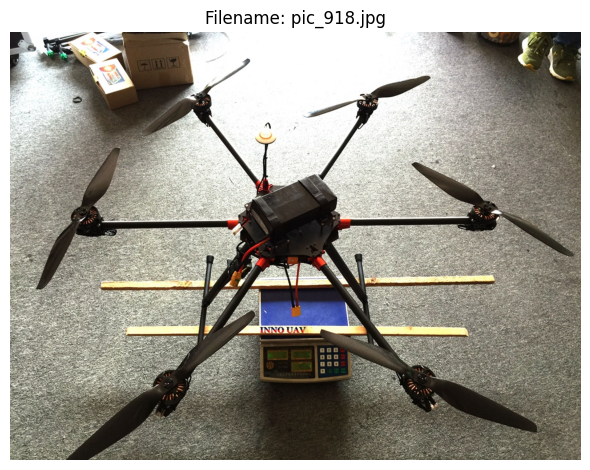

In [ ]:
def show_rand_img(path):
    """
    Display a single random image from a directory.

    Args:
        path: directory of image files
    """
    imgs_items = os.listdir(path)
    rand_img   = np.random.choice(imgs_items)
    plt.imshow(plt.imread(os.path.join(path, rand_img)))
    plt.title(f"Filename: {rand_img}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_rand_img(yaml_data['train'])

### 2.3 Object Crops from Labels

This function reads a YOLO label file, converts the normalised coordinates to pixel values, and crops each annotated object out of the image.
It optionally accepts a classifier and a box-drawing function to preview predictions on top of the crops.

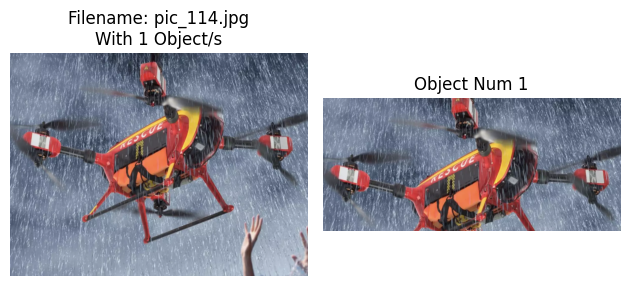

In [ ]:
def show_objects_by_coordinates(path, classifier=None, draw_box=None):
    """
    Pick a random image, crop each annotated object using its YOLO label,
    and display all crops side by side.

    Args:
        path      : directory of images (a matching 'labels' directory must exist alongside)
        classifier: optional function (crop) -> (label, confidence) applied to each crop
        draw_box  : optional function to draw a labelled box on the original image

    Returns:
        None — displays a matplotlib figure
    """
    imgs_items = os.listdir(path)
    rand_img   = np.random.choice(imgs_items)
    filename   = rand_img.split('.')
    img        = plt.imread(os.path.join(path, rand_img))
    h, w       = img.shape[:2]

    with open(os.path.join(path.replace('images', 'labels'), filename[0] + '.txt')) as f:
        coordinates_data = f.readlines()

    fig, ax = plt.subplots(1, len(coordinates_data) + 1)
    org_img = img.copy()

    for i, coord_item in enumerate(coordinates_data):
        cls, xc, yc, bw, bh = map(float, coord_item.split())

        # convert YOLO normalised [0,1] coords to pixel coordinates
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        ax[i + 1].imshow(img[y1:y2, x1:x2])

        if classifier:
            label, conf = classifier(img[y1:y2, x1:x2])
            if draw_box and classifier:
                draw_box(org_img, x1, y1, x2, y2, label, conf, thickness=8)
            ax[i + 1].set_title(f"Object Num {i+1}\nLabel: {label}\nConfidence: {(conf*100):.2f}%")
        else:
            ax[i + 1].set_title(f"Object Num {i+1}")

        ax[i + 1].axis('off')

    ax[0].imshow(org_img)
    ax[0].set_title(f"Filename: {rand_img}\nWith {len(coordinates_data)} Object/s")
    ax[0].axis('off')

    plt.tight_layout()
    plt.show()

show_objects_by_coordinates(yaml_data['train'])

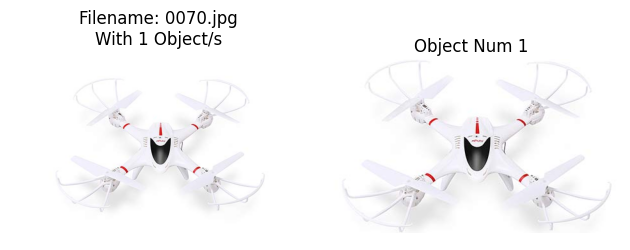

In [ ]:
show_objects_by_coordinates(yaml_data['val'])

## 3. Augmentation Preview

Each row shows a different image from the training set. Each column is an independent augmented version of that image.
This lets us verify that the augmentation pipeline looks realistic before training.

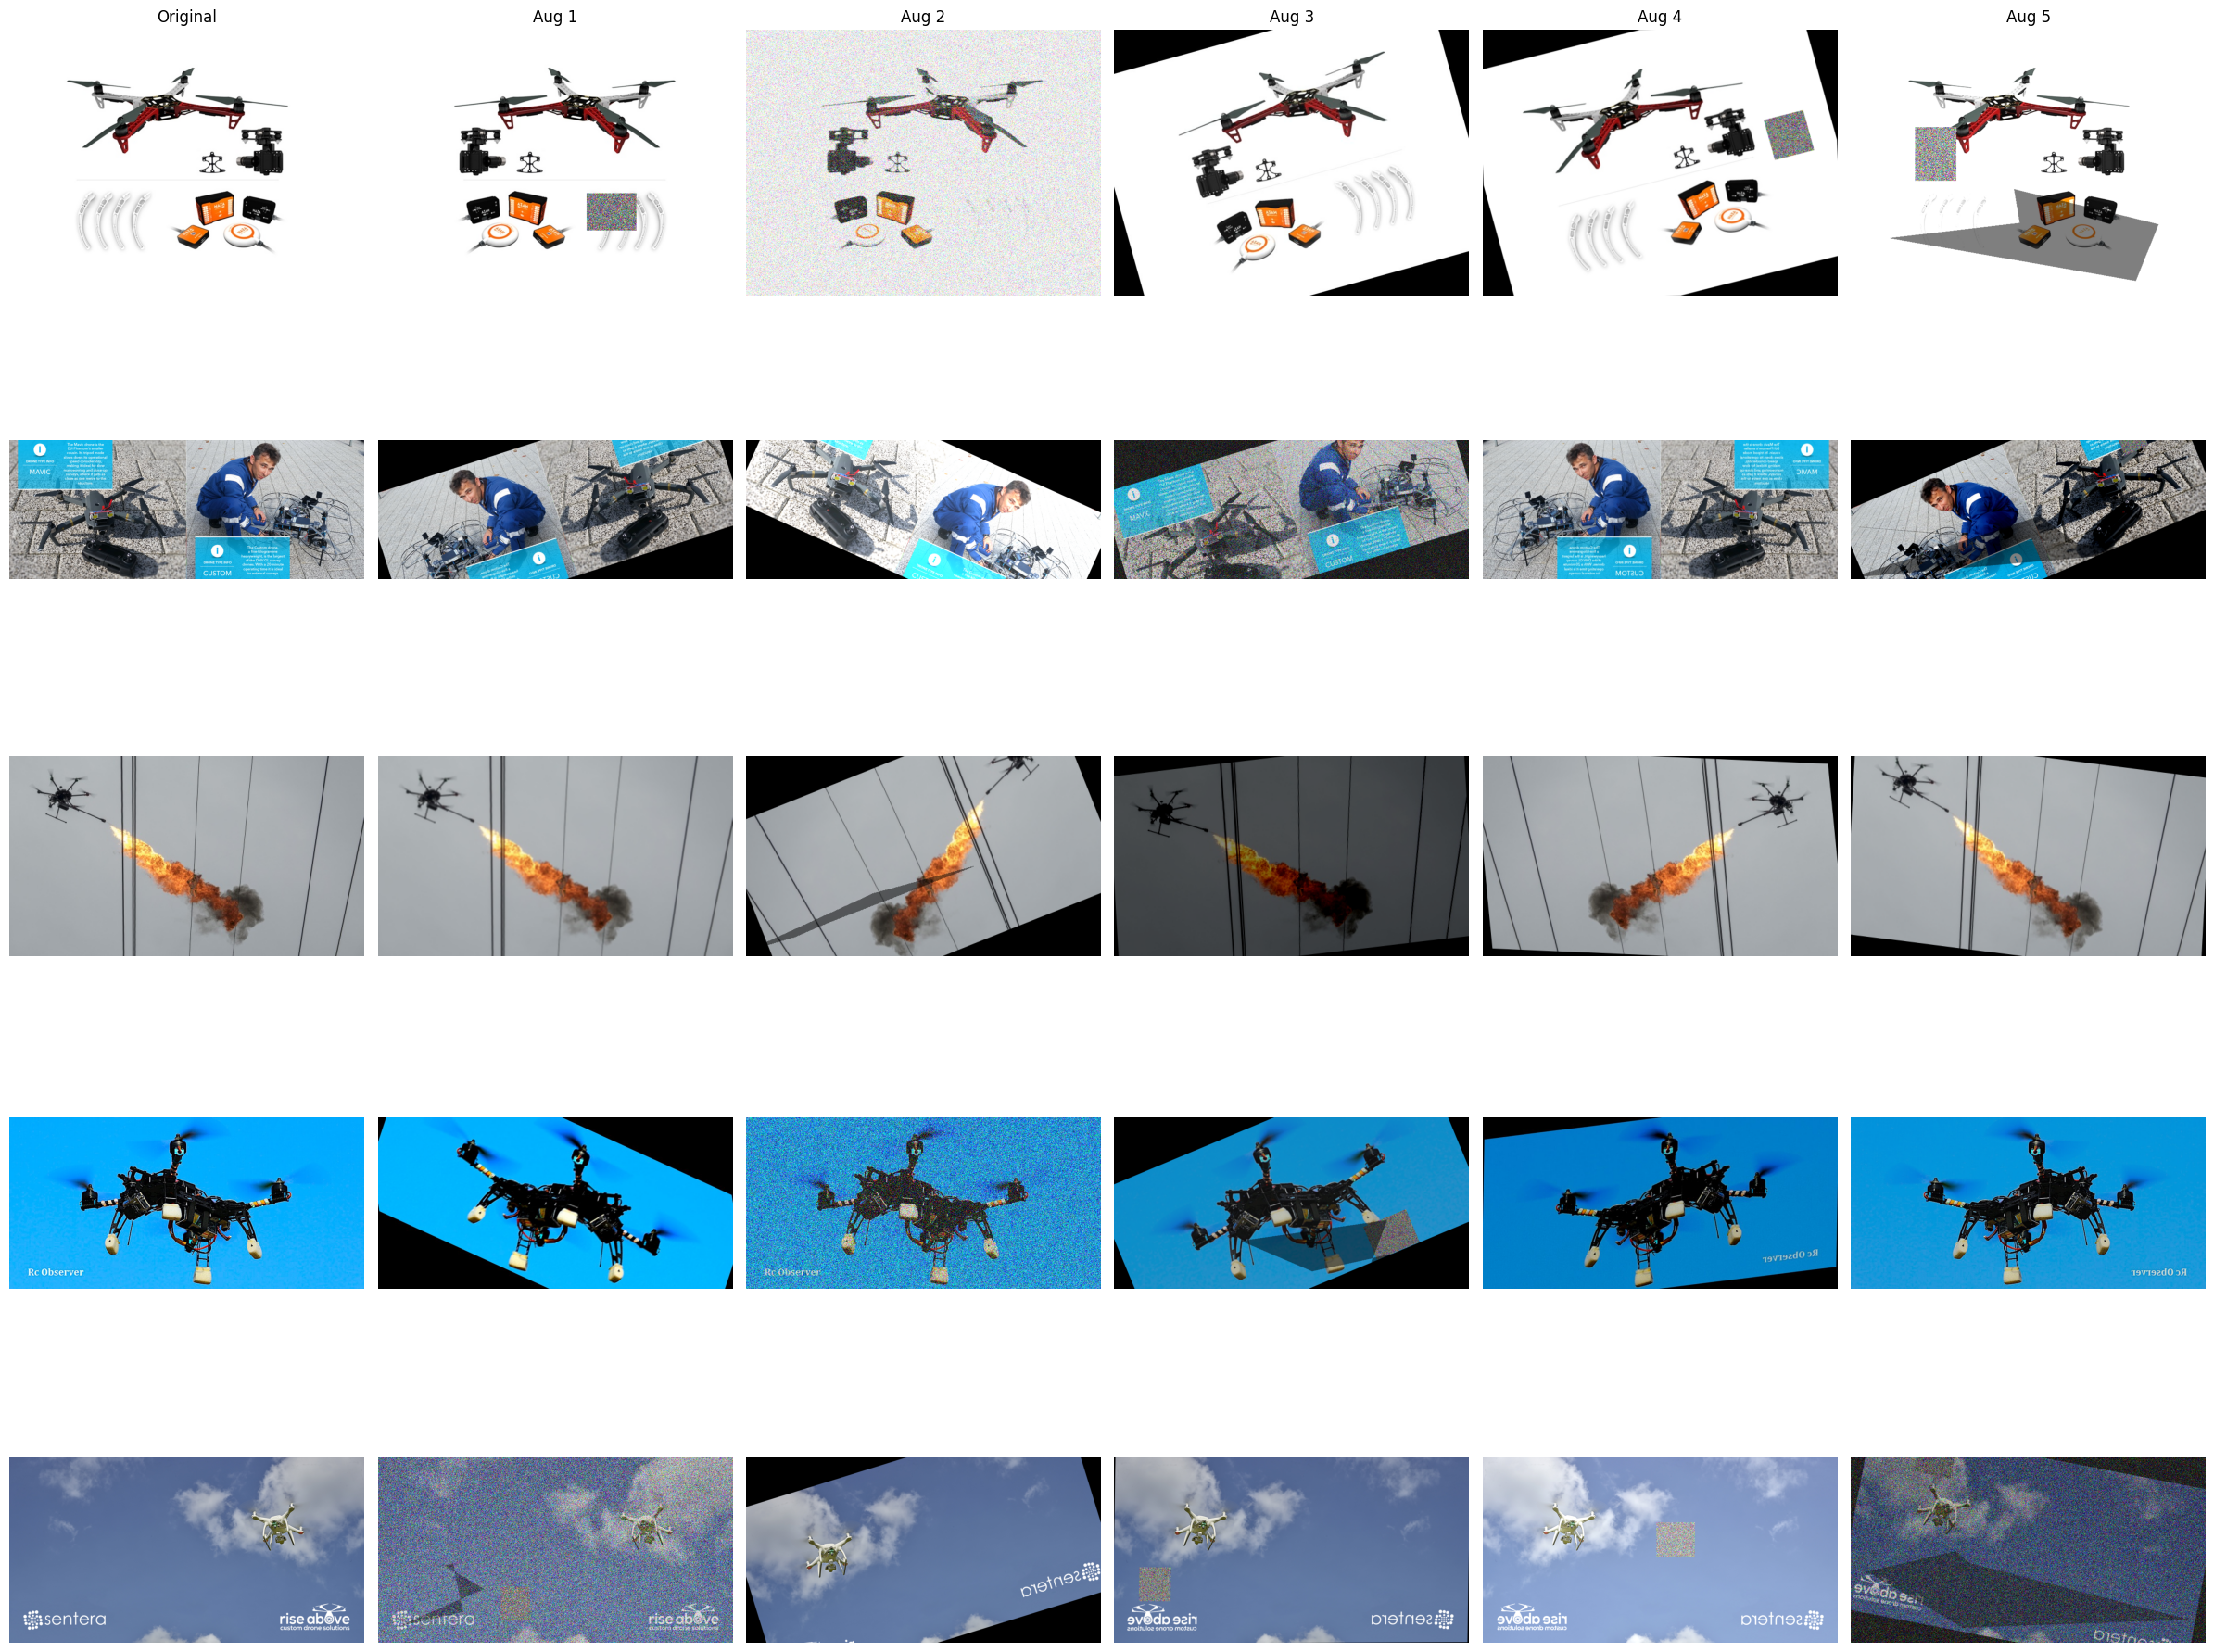

In [ ]:
def show_augmentations(path, transforms, rows=5, cols=5):
    """
    Display a grid of augmented images to preview the augmentation pipeline.

    Args:
        path      : directory of source images
        transforms: Albumentations Compose object
        rows      : number of source images (one per row)
        cols      : number of augmented variants per image
    """
    imgs_items = os.listdir(path)
    fig, axes  = plt.subplots(rows, cols + 1, figsize=(4 * (cols + 1), 4 * rows))

    for row in range(rows):
        rand_img = np.random.choice(imgs_items)
        image    = cv2.imread(os.path.join(path, rand_img), cv2.IMREAD_COLOR)
        # convert BGR (OpenCV default) to RGB for display
        image    = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, 0].imshow(image)
        axes[row, 0].set_title("Original" if row == 0 else "")
        axes[row, 0].axis("off")

        for col in range(1, cols + 1):
            augmented = transforms(image=image)["image"]
            axes[row, col].imshow(augmented)
            axes[row, col].set_title(f"Aug {col}" if row == 0 else "")
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

show_augmentations(yaml_data['train'], TRANSFORMS)

## 4. Drone Classifier (ResNet50)

YOLO26m sometimes mislabels drones as airplanes. To handle this we plug in a separate ResNet50 binary classifier trained to distinguish the two classes.

Whenever YOLO detects a `drone` or `airplane`, the crop is passed to this classifier, which overrides the label and confidence.

### 4.1 Load Classifier & Inference Function

The classifier expects a BGR crop (OpenCV format). We resize it to 224×224, apply ResNet50 preprocessing, and return the predicted label with its confidence score.

In [ ]:
classifier = load_model('..\drone_classifier_model.keras')

def drone_classifier(crop, input_size=224):
    """
    Run the ResNet50 binary classifier on an image crop.

    Args:
        crop     : BGR numpy array (H, W, 3) direct OpenCV output
        input_size: target size for ResNet50 input (default 224)

    Returns:
        tuple of (label string, confidence float in [0, 1])
    """
    image   = cv2.resize(crop, (input_size, input_size))
    # preprocess_input expects BGR and normalises to ImageNet stats
    image   = preprocess_input(image)
    image   = np.expand_dims(image, axis=0)
    y_pred  = classifier.predict(image, verbose=0)
    confidence = np.max(y_pred)

    if np.argmax(y_pred, axis=1):
        return 'Drone', confidence
    else:
        return 'Airplane', confidence

### 4.2 Visualise Classifier on Dataset

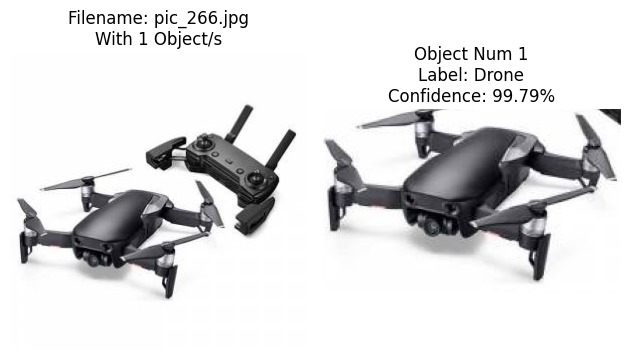

In [ ]:
show_objects_by_coordinates(yaml_data['train'],drone_classifier)

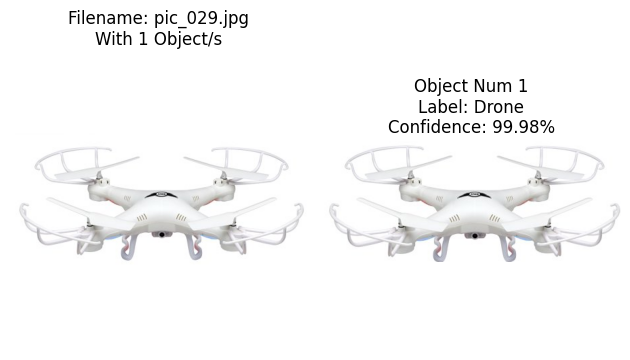

In [ ]:
show_objects_by_coordinates(yaml_data['val'],drone_classifier)

### 4.3 Visualise with Bounding Box Overlay

In [ ]:
def draw_corner_box(img, x1, y1, x2, y2, label_name, confidence, color=(0, 255, 0), length=35, thickness=3):
    """
    Draw a corner-style bounding box with a label badge on an image in-place.

    Args:
        img        : RGB numpy array to draw on (modified in place)
        x1, y1    : top-left corner in pixels
        x2, y2    : bottom-right corner in pixels
        label_name : class label string
        confidence : confidence score in [0, 1]
        color      : BGR colour tuple for the box and badge
        length     : length of each corner tick in pixels
        thickness  : line thickness in pixels
    """
    # draw L-shaped ticks at each corner
    cv2.line(img, (x1, y1), (x1 + length, y1), color, thickness)
    cv2.line(img, (x1, y1), (x1, y1 + length), color, thickness)
    cv2.line(img, (x2, y1), (x2 - length, y1), color, thickness)
    cv2.line(img, (x2, y1), (x2, y1 + length), color, thickness)
    cv2.line(img, (x1, y2), (x1 + length, y2), color, thickness)
    cv2.line(img, (x1, y2), (x1, y2 - length), color, thickness)
    cv2.line(img, (x2, y2), (x2 - length, y2), color, thickness)
    cv2.line(img, (x2, y2), (x2, y2 - length), color, thickness)

    # draw filled badge above the box, then write text on top
    text = f"{label_name} {confidence*100:.1f}%"
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(img, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
    cv2.putText(img, text, (x1 + 2, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

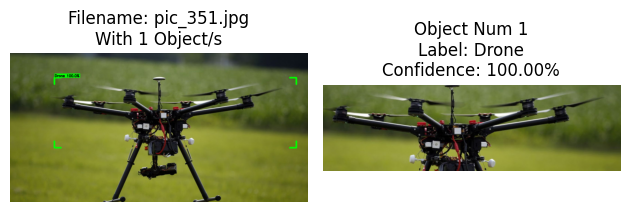

In [ ]:
show_objects_by_coordinates(yaml_data['train'],drone_classifier,draw_corner_box)

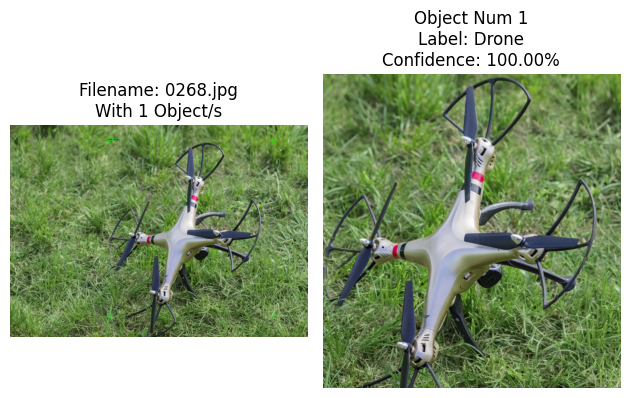

In [ ]:
show_objects_by_coordinates(yaml_data['val'],drone_classifier,draw_corner_box)

## 5. YOLO26m | Pre-Training Inference

### 5.1 Load Base Model

We load the pretrained YOLO26m weights. This gives us a baseline to compare against the fine-tuned version after training.

In [ ]:
yolo_model = YOLO('..\\yolo26m.pt')

### 5.2 Predict & Plot

`predict_with_plot` picks a random image, runs YOLO, and optionally passes each detection through the classifier.
When `apply_classifier=True`, any detection labelled `drone` or `airplane` is forwarded to the ResNet50 classifier, which overrides both the label and the confidence score.


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\yolo-drone-detector\yolo-drone-detector\..\..\..\..\World Of Datasets\Un-Structured Datasets\Object Detection\Drones Detection Dataset\drone_dataset\valid\images\0073.jpg: 416x640 1 airplane, 987.7ms
Speed: 3.7ms preprocess, 987.7ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 640)
Object 1 Name is Drone
The Coordinates is [63.56608963012695, 98.93189239501953, 544.7012939453125, 270.72161865234375]
Confidence Is 99.33%


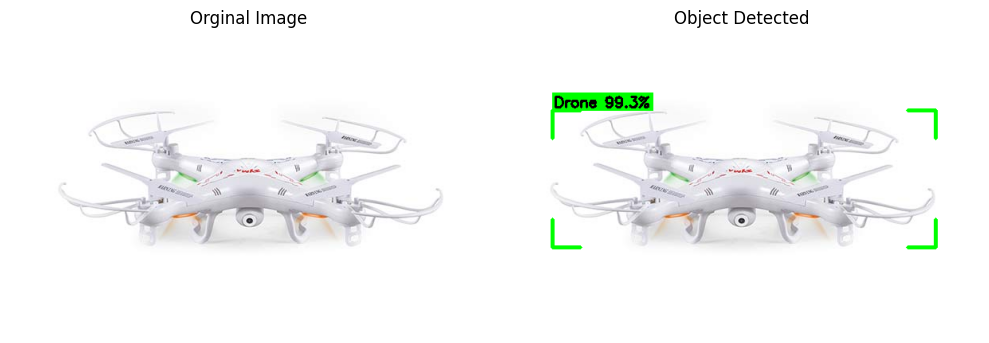

In [ ]:
def predict_with_plot(model, path, apply_classifier=None):
    """
    Run YOLO inference on a random image and display the result with labelled boxes.

    Args:
        model           : loaded Ultralytics YOLO model
        path            : directory of images to sample from
        apply_classifier: if True, pass drone/airplane crops through drone_classifier
    """
    imgs_items = os.listdir(path)
    rand_img   = np.random.choice(imgs_items)
    img_path   = os.path.join(path, rand_img)

    # keep BGR separately for the classifier; convert to RGB for display
    org_img = cv2.cvtColor(cv2.imread(img_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    outputs = yolo_model.predict(img_path, conf=CONF)
    output  = outputs[0]
    boxes   = output.boxes
    names   = output.names

    _, ax = plt.subplots(1, 2, figsize=(10, 15))
    ax[0].imshow(org_img)
    ax[0].set_title('Orginal Image')
    ax[0].axis('off')

    img_draw = org_img.copy()
    for i in range(len(boxes)):
        x1, y1, x2, y2 = map(int, boxes.xyxy[i].tolist())
        yolo_label      = names[boxes.cls[i].item()]
        coordinates     = boxes.xyxy[i].tolist()

        if apply_classifier and yolo_label.lower() in ['airplane', 'drone']:
            # override YOLO label with classifier result
            crop = org_img[y1:y2, x1:x2]
            label_name, confidence = drone_classifier(crop)
        else:
            label_name = yolo_label
            confidence = np.round(boxes.conf[i].item(), 2)

        draw_corner_box(img_draw, x1, y1, x2, y2, label_name, confidence)
        print(f"Object {i+1} Name is {label_name}")
        print(f"The Coordinates is {coordinates}")
        print(f"Confidence Is {confidence * 100:.2f}%")

    ax[1].imshow(img_draw)
    ax[1].set_title('Object Detected' if len(boxes) else 'No Detection')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()

predict_with_plot(yolo_model, yaml_data['val'], True)

## 6. Training

We fine-tune YOLO26m on the drone dataset using the hyperparameters defined in Section 1.3.
EarlyStopping is handled by the `patience` parameter training halts if mAP50 doesn't improve for 5 consecutive epochs.
The best weights are saved automatically to `Drone_Custom_YOLO_Results/weights/best.pt`.

In [ ]:
yolo_model.train(data=DATA_YAML_PATH,
                 epochs = EPOCHS,
                 imgsz = IMG_SIZE,
                 batch = BATCH_SIZE,
                 patience = PATIENCE,
                 optimizer = OPTIMIZER,
                 lr0 = LR0,
                 save=SAVE_WEIGHTS,
                 plots = PLOTS,
                 verbose = True,
                 device = DEVICE,
                 workers = NUM_OF_WORKERS,
                 augmentations = TRANSFORMS)

## 7. Evaluation

### 7.1 Test on Real-World Images

We load the fine-tuned model and run it on a completely separate set of real-world drone images that were never seen during training or validation.

In [ ]:
drone_yolo_model = YOLO(r'Drone_Custom_YOLO_Results\weights\best.pt')


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\yolo-drone-detector\yolo-drone-detector\..\..\..\..\World Of Datasets\Un-Structured Datasets\Object Detection\Natural Images\drones\70.JPEG: 448x640 1 bicycle, 1352.1ms
Speed: 8.7ms preprocess, 1352.1ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Object 1 Name is bicycle
The Coordinates is [486.378662109375, 378.43603515625, 1580.6990966796875, 905.51025390625]
Confidence Is 46.00%


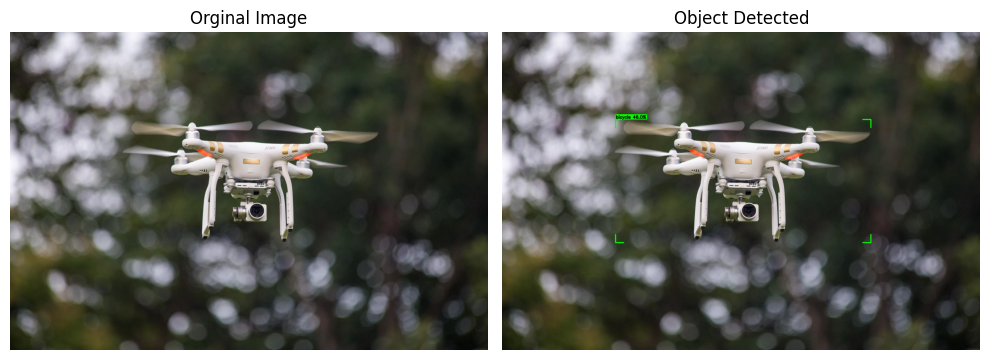

In [ ]:
# Test on real world images
predict_with_plot(drone_yolo_model,r'../../../../World Of Datasets/Un-Structured Datasets/Object Detection/Natural Images/drones',False)

### 7.2 Confusion Matrix

The confusion matrix gives us a clear picture of where the model makes mistakes false positives (background detected as drone) and false negatives (drones missed).

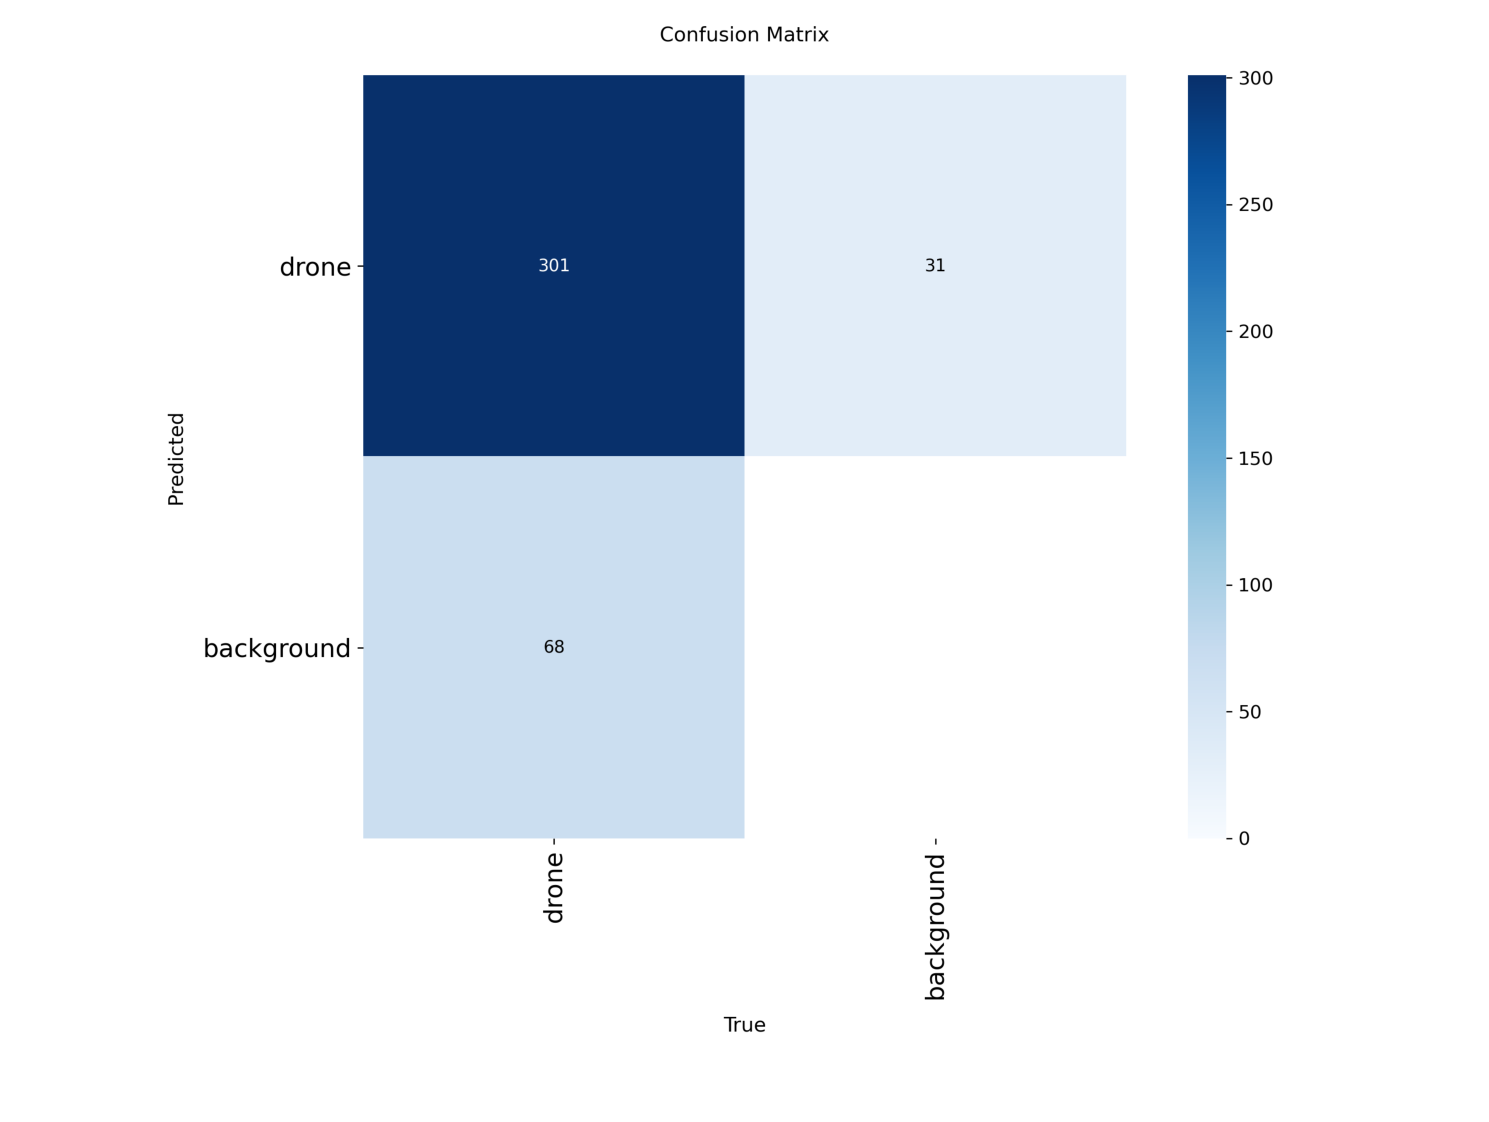

In [ ]:
def show_result(path):
    """Display a saved result image at a readable size."""
    plt.figure(figsize=(15, 15))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_result('Drone_Custom_YOLO_Results/confusion_matrix/confusion_matrix.png')

### 7.3 Training Curves

`results.png` shows loss and mAP curves across all epochs the key chart for reporting model performance.

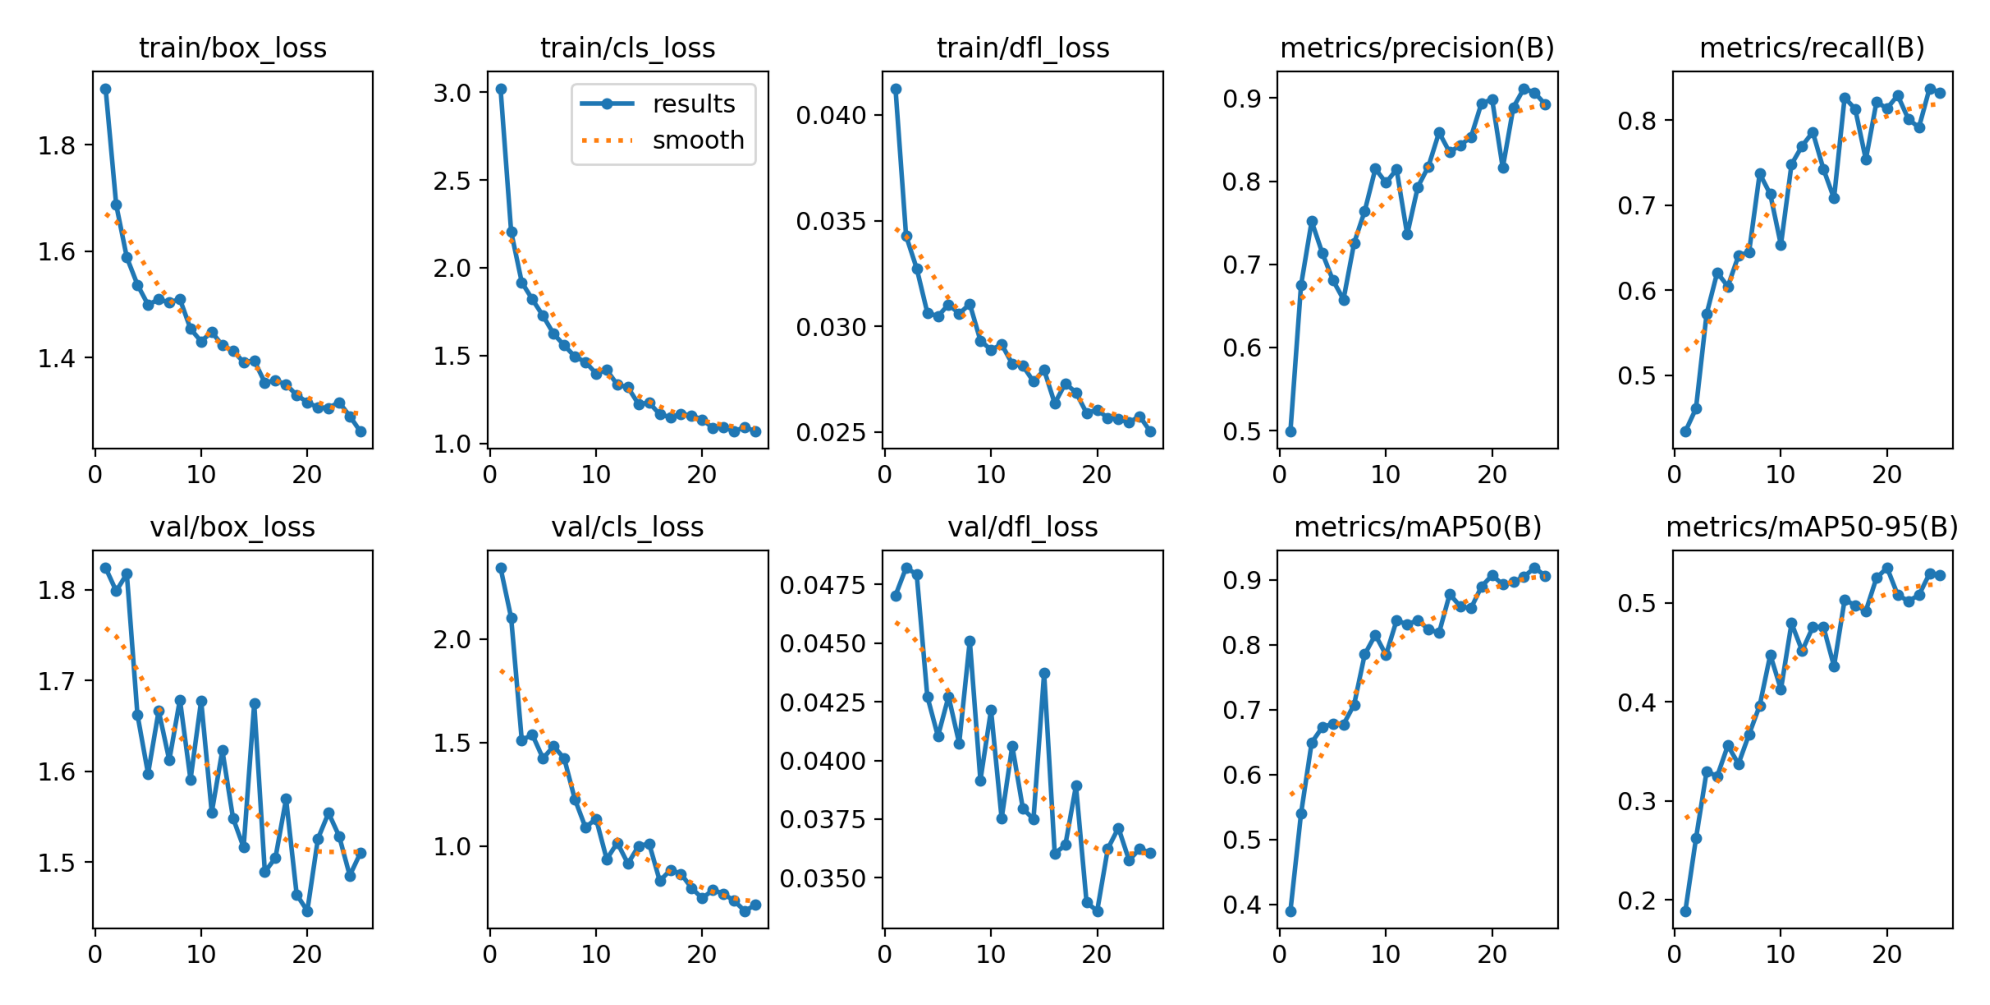

In [ ]:
def show_result(path):
    """Display a saved result image at a readable size."""
    plt.figure(figsize=(20, 20))
    plt.imshow(plt.imread(path))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_result('Drone_Custom_YOLO_Results/results.png')